# <span style="color:red; font-weight:bold">MSE loss for DL models + XGBoost(No quantile)</span>

## <span style="color:blue; font-weight:bold"> Testing stage (train+val vs test)</span>

### Import dataset

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("wandb_mse_updated.csv")

df_test = df[
    (df['testing_stage'] == True) &         # Only test stage runs
    (df['data_augmentation'] == False)      # Only non-augmented runs
].copy()

### Boxplots of the forecasters

/tmp/ipykernel_184177/1950701895.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_184177/1950701895.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_184177/1950701895.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


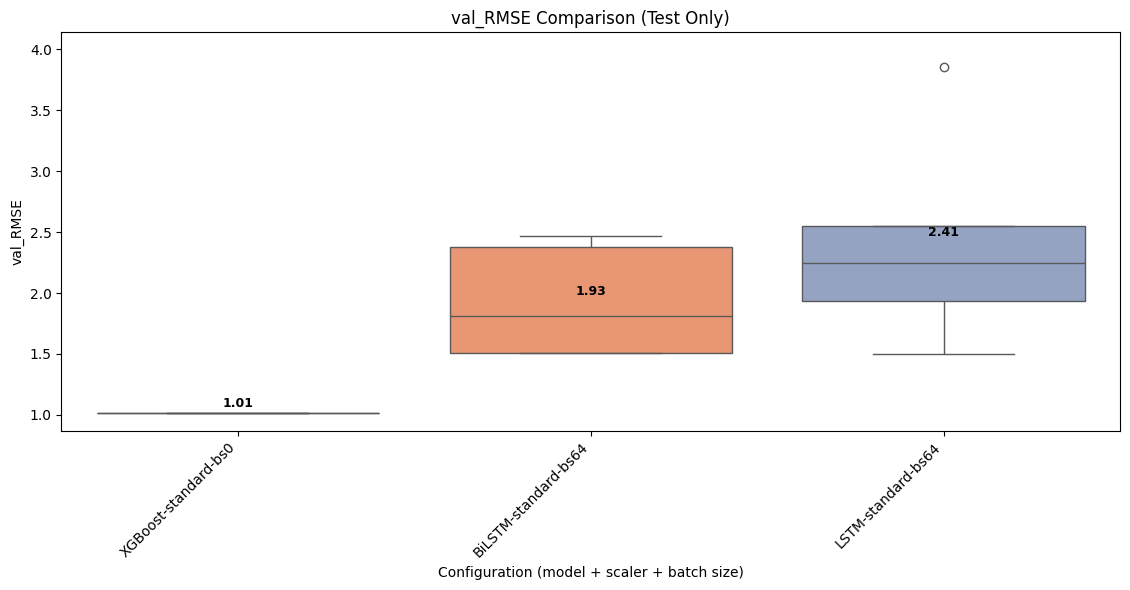

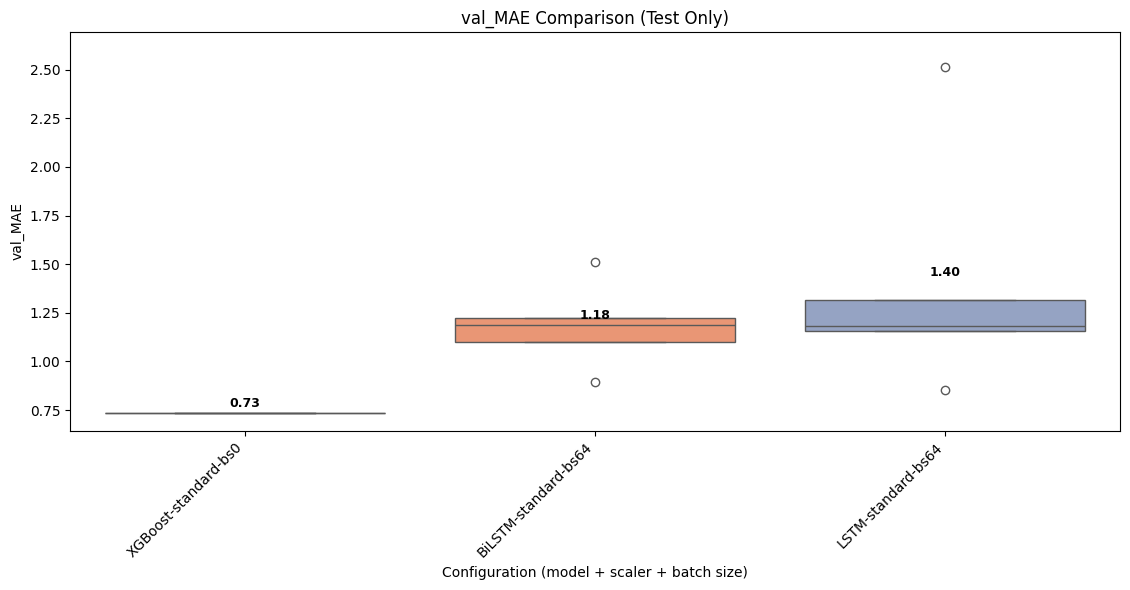

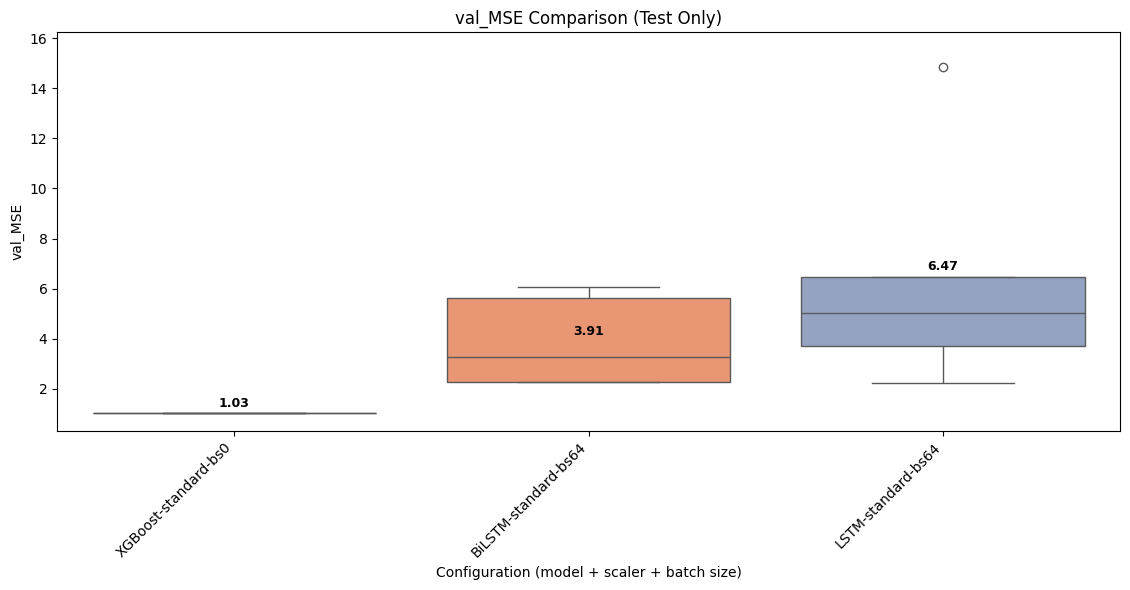

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_test_boxplots(metric, df_test):
    # Build config_name
    df_test = df_test.copy()
    df_test['config_name'] = (
        df_test['model_name'] + '-' +
        df_test['scaler_name'] + '-bs' +
        df_test['batch_size'].astype(str)
    )

    # Order configurations by mean metric value
    order = df_test.groupby('config_name')[metric].mean().sort_values().index

    # Compute offset for annotations
    y_min = df_test[metric].min()
    y_max = df_test[metric].max()
    y_range = y_max - y_min
    offset = 0.01 * y_range

    # Plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_test,
        x='config_name',
        y=metric,
        order=order,
        palette='Set2'
    )

    # Add mean annotations
    grouped = df_test.groupby('config_name')[metric].mean()
    for i, config in enumerate(order):
        val = grouped[config]
        plt.text(
            i, val + offset, f"{val:.2f}",
            ha='center', va='bottom', fontsize=9,
            color='black', fontweight='bold'
        )

    # Labels and layout
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Configuration (model + scaler + batch size)")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison (Test Only)")
    plt.ylim(y_min - 0.05 * y_range, y_max + 0.1 * y_range)
    plt.tight_layout(rect=[0, 0, 0.95, 1])

    # Save
    plt.savefig(f"Plots/boxplot_{metric}_test_only.png")
    # plt.show()c

# Run for all metrics
metrics = ['val_RMSE', 'val_MAE', 'val_MSE']
for metric in metrics:
    plot_test_boxplots(metric, df_test)

### heatmap of metrics vs forecasters

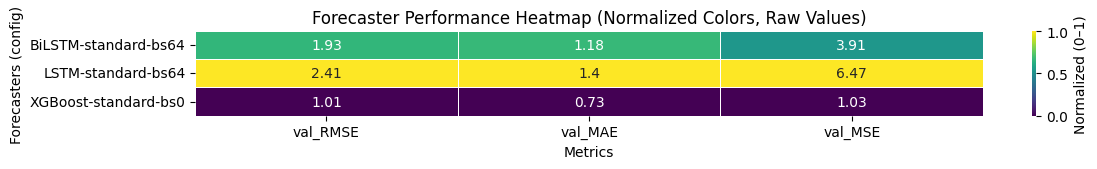

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create config_name if needed
df_test['config_name'] = df_test['model_name'] + '-' + df_test['scaler_name'] + '-bs' + df_test['batch_size'].astype(str)

# 2. Metrics and average values
metrics = ['val_RMSE', 'val_MAE', 'val_MSE']
heatmap_data = df_test.groupby('config_name')[metrics].mean()

# 3. Normalize for coloring
normalized = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

# 4. Plot heatmap
plt.figure(figsize=(12, len(heatmap_data) * 0.6))
sns.heatmap(
    normalized,
    annot=heatmap_data.round(2),  # show real values
    fmt='',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Normalized (0–1)'},
)

plt.title("Forecaster Performance Heatmap (Normalized Colors, Raw Values)")
plt.xlabel("Metrics")
plt.ylabel("Forecasters (config)")
plt.tight_layout()
# plt.show()
plt.savefig(f"Plots/heatmap_mse_testing.png")


## <span style="color:green; font-weight:bold"> Data Augmentation stage</span>

### Import dataset

In [4]:
import pandas as pd

df = pd.read_csv("wandb_mse_updated.csv")

df_aug = df[
    (df['testing_stage'] == True) &         # Only test stage runs
    (df['data_augmentation'] == True)       # Only augmented runs
].copy()

### Compute Lift metric plots

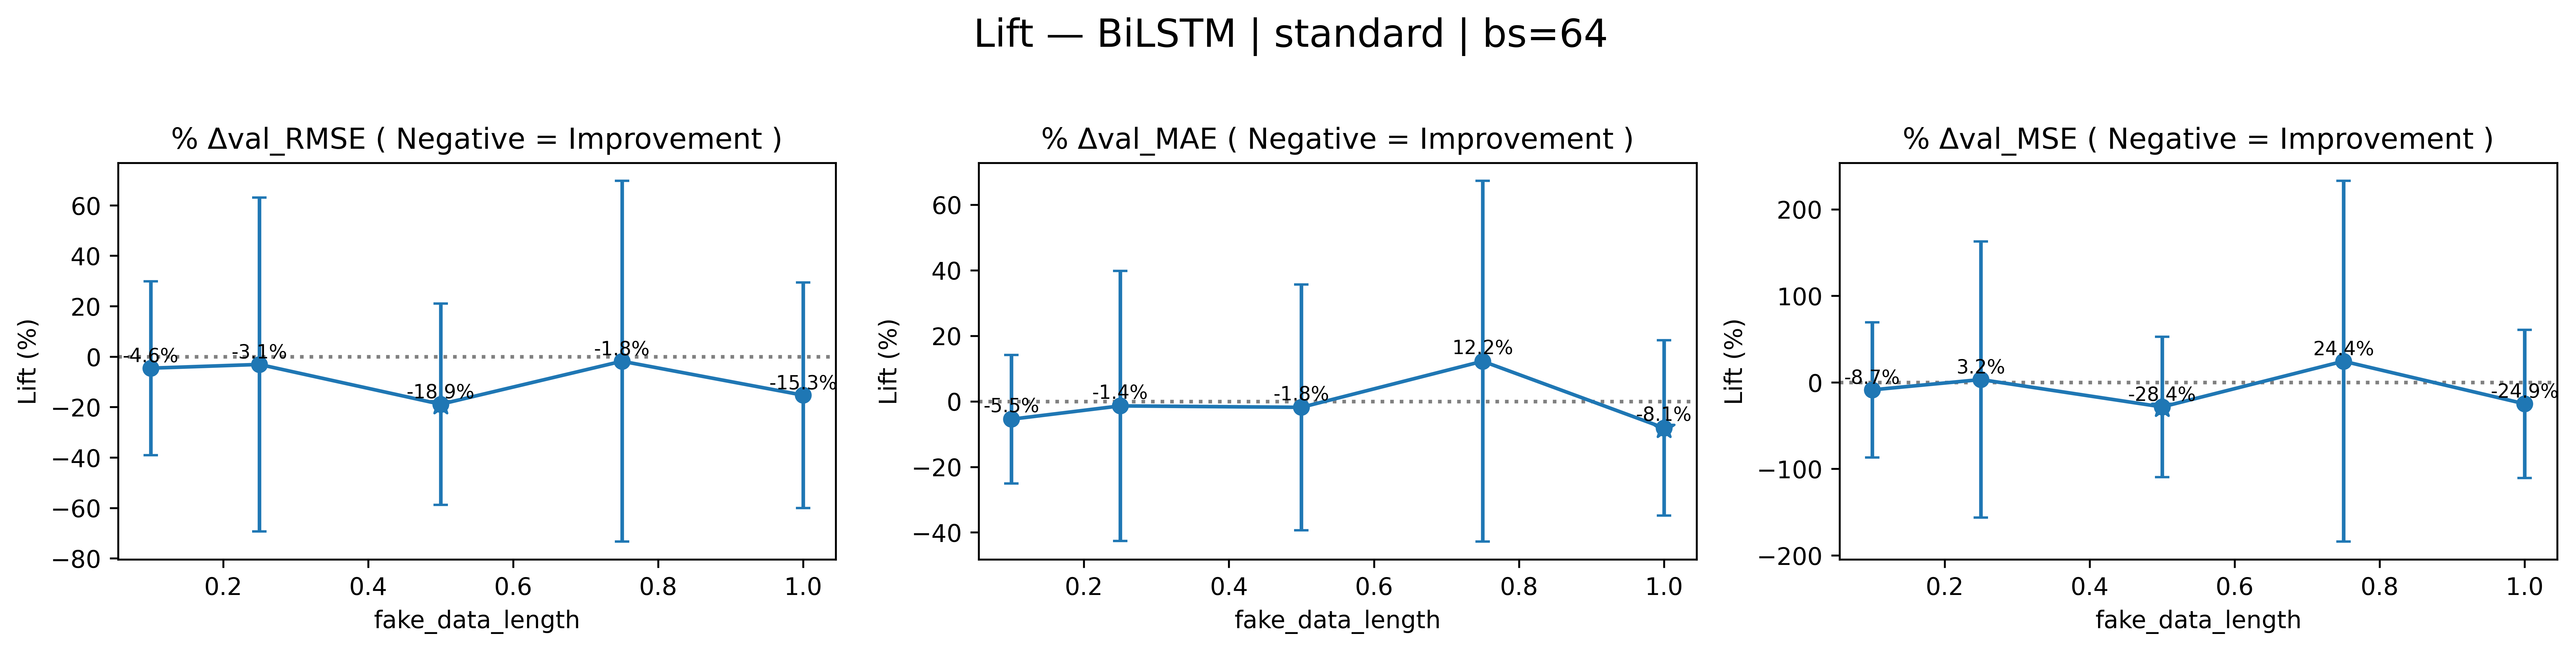

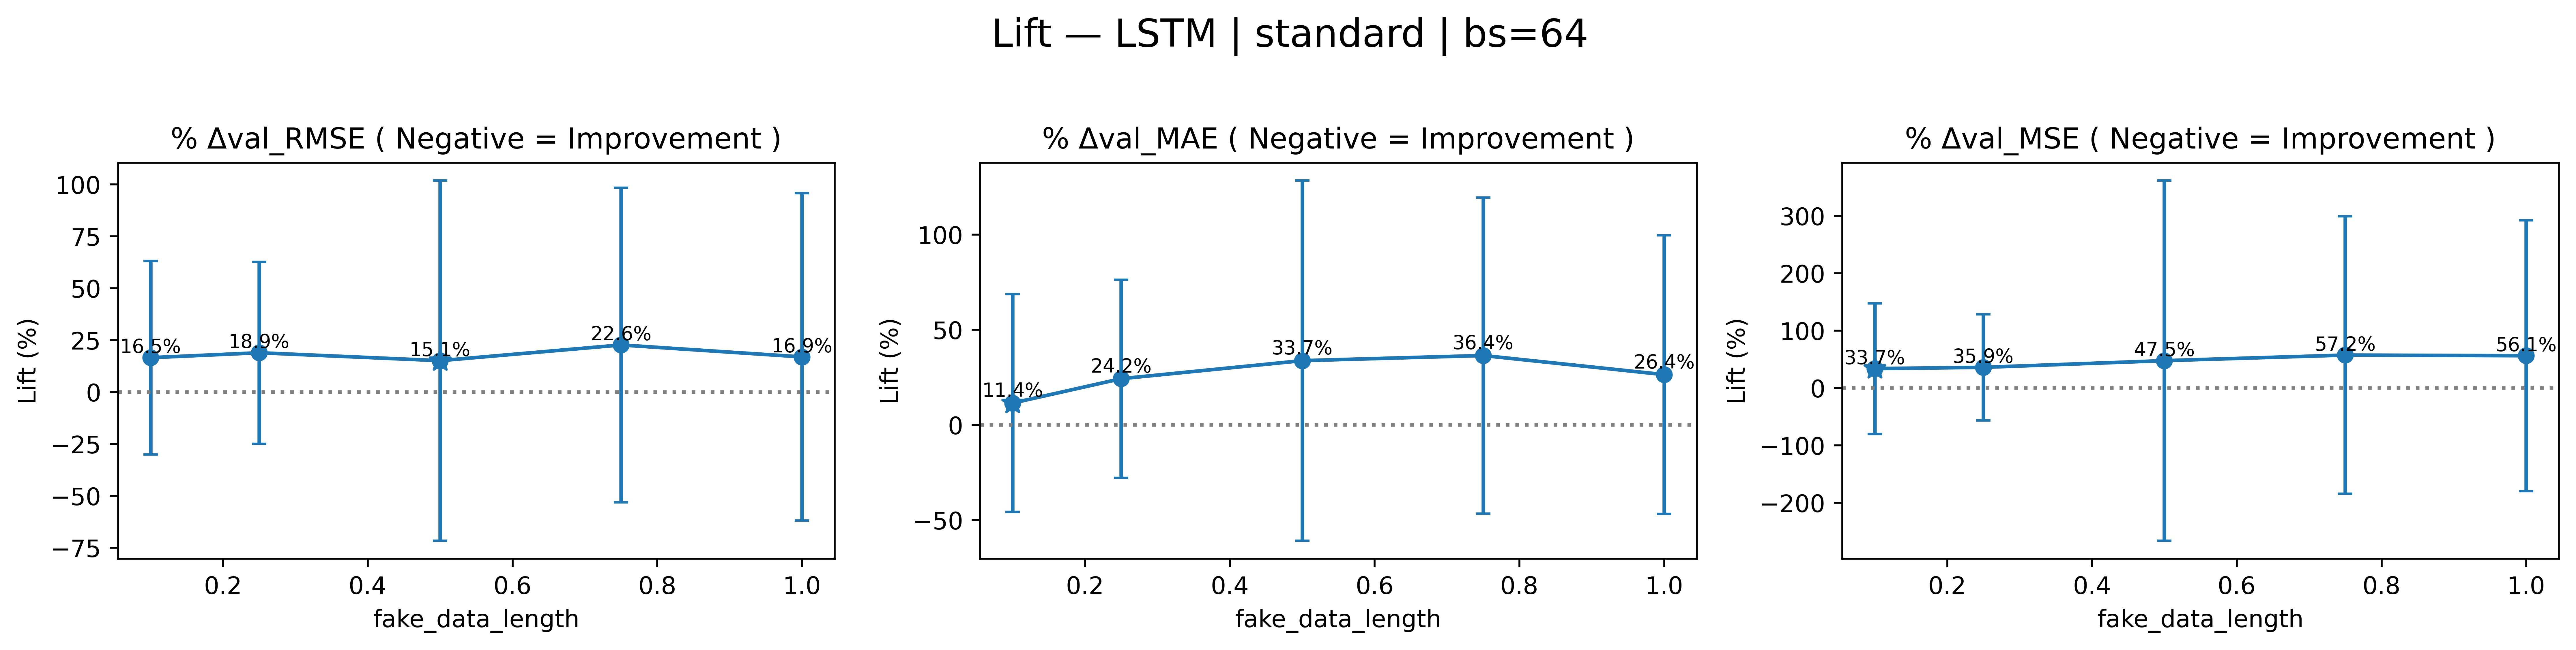

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# ---- CONFIG ----
METRICS = ['val_RMSE', 'val_MAE', 'val_MSE']
GOOD_METRICS = set()  # metrics where higher is better (only affects titles)


# ---- 1) Build paired baseline/augmented rows (same seed) ----
def build_paired(df, metrics=METRICS):
    """
    Keep only test-stage rows, pair each augmented run with its own baseline
    for the same (model, scaler, batch, seed).
    Returns a DataFrame with both aug and base columns present.
    """
    df_all = df[df['testing_stage'] == True].copy()

    keys = ['model_name', 'scaler_name', 'batch_size', 'seed']
    base = df_all[df_all['data_augmentation'] == False][keys + metrics].copy()
    aug  = df_all[df_all['data_augmentation'] == True][keys + ['fake_data_length'] + metrics].copy()

    base = base.rename(columns={m: f'{m}_base' for m in metrics})

    paired = aug.merge(base, on=keys, how='inner', validate='many_to_one')
    # helpful labels
    paired['config_base'] = (
        paired['model_name'] + ' | ' + paired['scaler_name'] + f" | bs={paired['batch_size'].astype(str)}"
    )
    return paired

# ---- 2) Compute per-seed lift and aggregate mean/std per fake ratio ----
def compute_lift_stats_of_means(paired, metrics):
    """
    For each (model, scaler, batch, fake_data_length):
        - take mean of seeds for augmented and baseline
        - compute % lift between these means
        - compute std of per-seed lifts for error bars
    """
    out_rows = []
    group_keys = ['model_name','scaler_name','batch_size','fake_data_length']

    for metric in metrics:
        # means across seeds
        g = paired.groupby(group_keys)
        mean_aug  = g[metric].mean()
        mean_base = g[f'{metric}_base'].mean()
        lift_mean = ((mean_aug - mean_base) / mean_base * 100.0).rename('mean').reset_index()

        # std across per-seed lifts (name the column!)
        tmp = paired[group_keys].copy()
        tmp['lift_pct'] = ((paired[metric] - paired[f'{metric}_base']) / paired[f'{metric}_base'] * 100.0)
        lift_std = tmp.groupby(group_keys)['lift_pct'].std().reset_index().rename(columns={'lift_pct':'std'})

        # combine
        df_tmp = lift_mean.merge(lift_std, on=group_keys, how='left')
        df_tmp['metric'] = metric
        out_rows.append(df_tmp)

    return pd.concat(out_rows, ignore_index=True)


# ---- 3) Plot: one figure per (model, scaler, batch), subplots per metric ----
def plot_lift(stats_df, save_dir=None, dpi=300, ncols=3):
    """
    stats_df is the output of compute_lift_stats.
    Creates one figure per (model, scaler, batch), with panels for each metric.
    """
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    groups = stats_df[['model_name','scaler_name','batch_size']].drop_duplicates()

    for _, g in groups.iterrows():
        sub = stats_df[
            (stats_df['model_name']==g['model_name']) &
            (stats_df['scaler_name']==g['scaler_name']) &
            (stats_df['batch_size']==g['batch_size'])
        ].copy()

        # keep metric order consistent with METRICS
        sub['metric'] = pd.Categorical(sub['metric'], METRICS, ordered=True)
        sub = sub.sort_values(['metric','fake_data_length'])

        nmetrics = len(METRICS)
        nrows = int(np.ceil(nmetrics / ncols))
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 3.6*nrows), dpi=dpi)
        axes = np.array(axes).reshape(-1)
        for ax in axes[nmetrics:]:
            ax.axis('off')

        for i, metric in enumerate(METRICS):
            ax = axes[i]
            msub = sub[sub['metric'] == metric]
            if msub.empty:
                ax.axis('off')
                continue

            ax.errorbar(msub['fake_data_length'], msub['mean'], yerr=msub['std'],
                        marker='o', capsize=3, linestyle='-')

            # annotate values
            yr = (msub['mean'].max() - msub['mean'].min())
            y_offset = 0.05 * (yr if np.isfinite(yr) and yr != 0 else 1.0)
            for x, y in zip(msub['fake_data_length'], msub['mean']):
                ax.text(x, y + y_offset, f"{y:.1f}%", ha='center', va='bottom', fontsize=8)

            # highlight best direction
            title_dir = "Positive = Improvement" if any(t in metric.upper() for t in GOOD_METRICS) \
                        else "Negative = Improvement"
            ax.axhline(0, ls=':', c='gray')
            ax.set_title(f"% Δ{metric} ( {title_dir} )")
            ax.set_xlabel("fake_data_length")
            ax.set_ylabel("Lift (%)")

            # star the best mean point
            if any(t in metric.upper() for t in GOOD_METRICS):
                idx = msub['mean'].idxmax()
            else:
                idx = msub['mean'].idxmin()
            ax.scatter(msub.loc[idx,'fake_data_length'],
                       msub.loc[idx,'mean'], marker='*', s=80, zorder=5)

        fig.suptitle(f"Lift — {g['model_name']} | {g['scaler_name']} | bs={g['batch_size']}", y=1.03, fontsize=16)
        fig.tight_layout()

        if save_dir:
            fname = f"lift_{g['model_name']}_{g['scaler_name']}_bs{g['batch_size']}.png".replace(" ", "")
            plt.savefig(os.path.join(save_dir, fname), bbox_inches='tight', dpi=dpi)

        plt.show()

# ---- RUN ----
# df must already be your full dataframe with the columns used above
paired = build_paired(df, METRICS)
lift_stats = compute_lift_stats_of_means(paired, METRICS)
plot_lift(lift_stats, save_dir="lift_plots_PF", dpi=600, ncols=3)

### heatmap of metrics vs forecasters (With Augmentation)

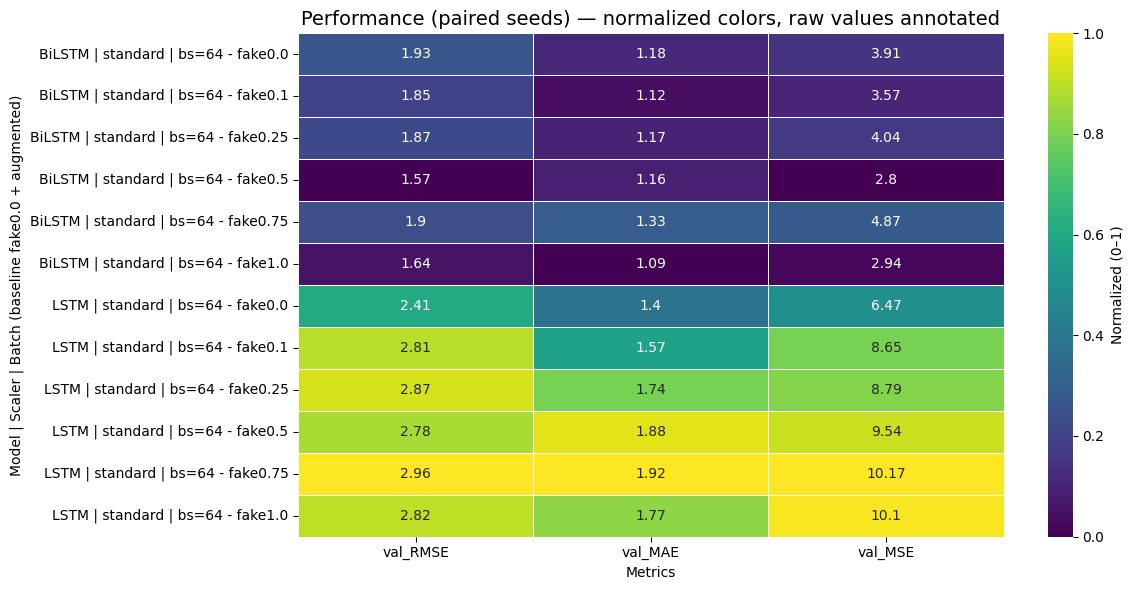

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

METRICS = ['val_RMSE', 'val_MAE', 'val_MSE']

# 1) Build a neat label and compute means over the SAME seeds used in paired
paired['config_base_lbl'] = (
    paired['model_name'] + ' | ' + paired['scaler_name'] + ' | bs=' + paired['batch_size'].astype(str)
)
paired['config_full'] = paired['config_base_lbl'] + ' - fake' + paired['fake_data_length'].astype(str)

# 2) Means for augmented (by fake ratio) and baseline (paired-only)
aug_means = (paired
    .groupby('config_full')[METRICS]
    .mean()
)

base_means = (paired
    .groupby('config_base_lbl')[[m + '_base' for m in METRICS]]
    .mean()
    .rename(columns={m + '_base': m for m in METRICS})
)
# give baseline rows a consistent label to appear before the fakes
base_means.index = base_means.index + ' - fake0.0'

# 3) Combine and sort
heatmap_data = pd.concat([base_means, aug_means], axis=0).sort_index()

# 4) Normalize per metric for colors; annotate with raw values
normalized = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(12, max(6, 0.45*len(heatmap_data))))
sns.heatmap(
    normalized,
    annot=heatmap_data.round(2),
    fmt='',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label':'Normalized (0–1)'}
)
plt.title("Performance (paired seeds) — normalized colors, raw values annotated", fontsize=14)
plt.xlabel("Metrics")
plt.ylabel("Model | Scaler | Batch (baseline fake0.0 + augmented)")
plt.tight_layout()
plt.savefig("Plots/heatmap_paired_raw.png", dpi=300)
plt.show()


# <span style="color:red; font-weight:bold">Pinball loss for DL models + XGBoost(quantile)</span>

## <span style="color:blue; font-weight:bold"> Testing stage (train+val_1 vs test)</span>

### Import dataset

In [7]:
import numpy as np
import pandas as pd

df = pd.read_csv("wandb_pinball_updated.csv")

# # Concatenate the TFT runs
# df_TFT = pd.read_csv("TFT_pinball.csv", usecols=[c for c in df.columns if c in pd.read_csv("TFT_pinball.csv", nrows=0).columns])
# # Reindex df2 to ensure it has exactly the same columns/order as df1
# df_TFT = df_TFT.reindex(columns=df.columns)
# df = pd.concat([df, df_TFT], ignore_index=True)

df_test = df[
    (df['testing_stage'] == True) &         # Only test stage runs
    (df['data_augmentation'] == False)      # Only non-augmented runs
].copy()

### Boxplots of the forecasters

/tmp/ipykernel_184177/813827221.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_184177/813827221.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_184177/813827221.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


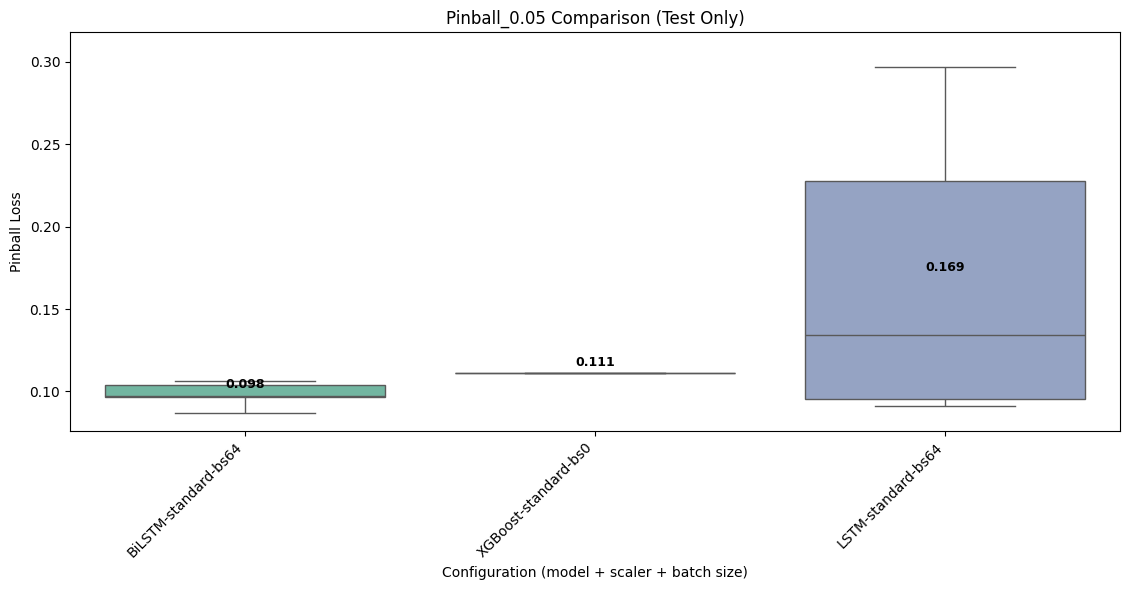

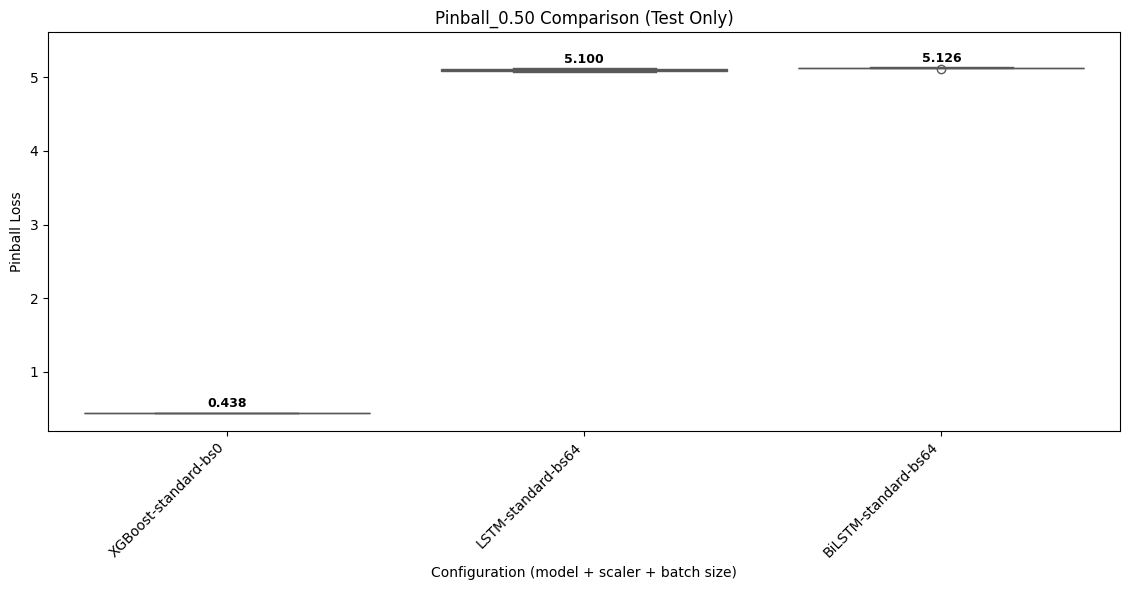

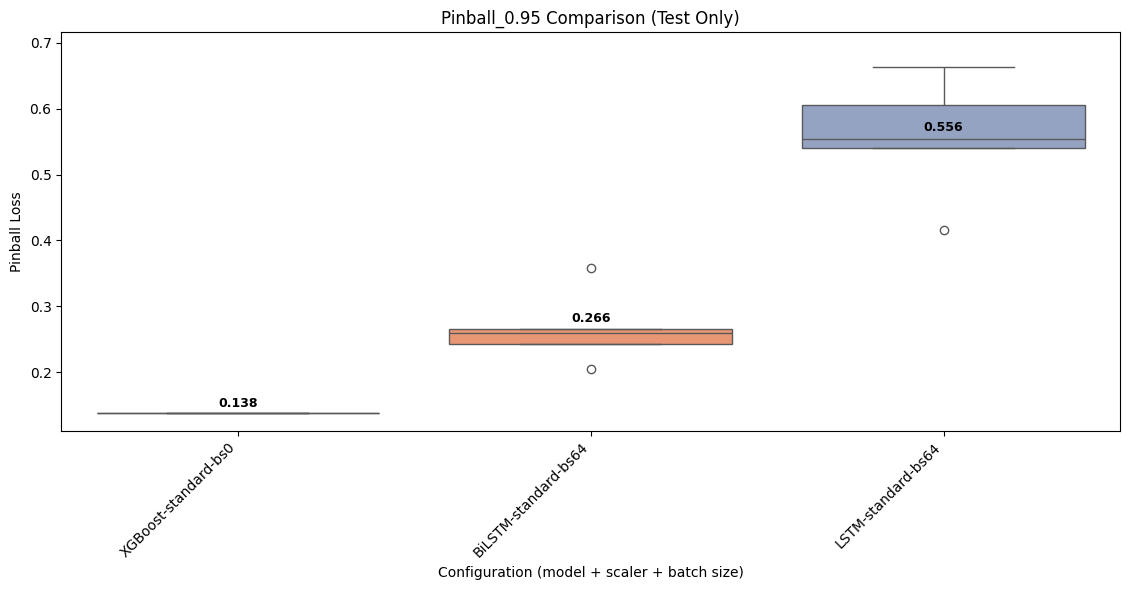

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_test_boxplots_pinball(df_test, pinball_cols=None):
    """
    Test-only boxplots for pinball losses, matching the style of your point-forecasting plots.
    - Builds `config_name` the same way
    - Orders configs by mean (Test) pinball value
    - Annotates Test means above each box
    - Saves to: Plots/boxplot_Pinball_{q}_test_only.png
    """
    if pinball_cols is None:
        pinball_cols = ['Pinball_0.05', 'Pinball_0.50', 'Pinball_0.95']

    # Copy & build config_name like point-forecasting
    df = df_test.copy()
    if 'config_name' not in df.columns:
        df['config_name'] = (
            df['model_name'] + '-' +
            df['scaler_name'] + '-bs' +
            df['batch_size'].astype(str)
        )

    # Melt to long format: one row per (config, quantile, value)
    df_long = df.melt(
        id_vars=['model_name', 'scaler_name', 'batch_size', 'seed', 'Name', 'config_name'],
        value_vars=pinball_cols,
        var_name='quantile',
        value_name='pinball_loss'
    )
    # Extract numeric quantile for cleaner filenames/titles (0.05, 0.50, 0.95)
    df_long['q'] = df_long['quantile'].str.extract(r'(\d+\.\d+)').astype(float)

    # Plot each quantile separately, matching point-forecasting style
    for q in sorted(df_long['q'].unique()):
        sub = df_long[df_long['q'] == q].copy()
        metric = f'Pinball_{q:.2f}'

        # Order configurations by mean pinball (Test only)
        order = sub.groupby('config_name')['pinball_loss'].mean().sort_values().index

        # Compute offsets for annotations/limits
        y_min = sub['pinball_loss'].min()
        y_max = sub['pinball_loss'].max()
        y_range = max(y_max - y_min, 1e-12)
        offset = 0.01 * y_range

        # Plot
        plt.figure(figsize=(12, 6))
        sns.boxplot(
            data=sub,
            x='config_name',
            y='pinball_loss',
            order=order,
            palette='Set2'
        )

        # Mean annotations
        grouped = sub.groupby('config_name')['pinball_loss'].mean()
        for i, config in enumerate(order):
            val = grouped[config]
            plt.text(
                i, val + offset, f"{val:.3f}",
                ha='center', va='bottom', fontsize=9,
                color='black', fontweight='bold'
            )

        # Labels and layout (mirrors your point-forecasting function)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel("Configuration (model + scaler + batch size)")
        plt.ylabel("Pinball Loss")
        plt.title(f"{metric} Comparison (Test Only)")
        plt.ylim(y_min - 0.05 * y_range, y_max + 0.1 * y_range)
        plt.tight_layout(rect=[0, 0, 0.95, 1])

        # Save
        plt.savefig(f"Plots/boxplot_{metric}_test_only.png")
        # plt.show()

# --- Run for all pinball quantiles (Test only) ---
plot_test_boxplots_pinball(df_test, pinball_cols=['Pinball_0.05', 'Pinball_0.50', 'Pinball_0.95'])


### heatmap of metrics vs forecasters

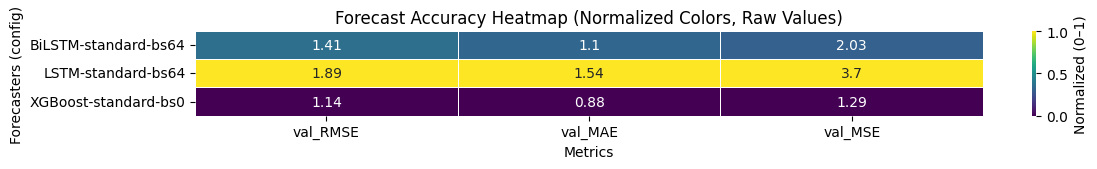

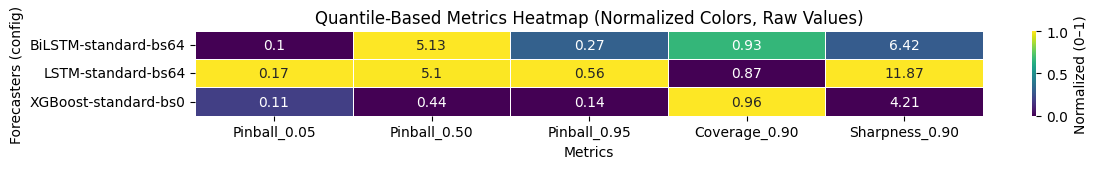

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# === STEP 1: Create config name if needed ===
df_test['config_name'] = (
    df_test['model_name'] + '-' +
    df_test['scaler_name'] + '-bs' +
    df_test['batch_size'].astype(str)
)
    
# === STEP 2: Standard forecast metrics ===
standard_metrics = ['val_RMSE', 'val_MAE', 'val_MSE']
standard_data = df_test.groupby('config_name')[standard_metrics].mean()
standard_norm = (standard_data - standard_data.min()) / (standard_data.max() - standard_data.min())

# === STEP 3: Quantile-aware metrics ===
quantile_metrics = ['Pinball_0.05', 'Pinball_0.50', 'Pinball_0.95', 'Coverage_0.90', 'Sharpness_0.90']
quantile_data = df_test.groupby('config_name')[quantile_metrics].mean()
quantile_norm = (quantile_data - quantile_data.min()) / (quantile_data.max() - quantile_data.min())

# === STEP 4: Plot heatmaps ===

def plot_heatmap(data, normalized, title):
    plt.figure(figsize=(12, len(data) * 0.6))
    sns.heatmap(
        normalized,
        annot=data.round(2),
        fmt='',
        cmap='viridis',
        linewidths=0.5,
        cbar_kws={'label': 'Normalized (0–1)'}
    )
    plt.title(title)
    plt.xlabel("Metrics")
    plt.ylabel("Forecasters (config)")
    plt.tight_layout()
    if title.startswith("Forecast"): #standard metrics
        plt.savefig(f"Plots/heatmap_stand_pinball_testing.png")
    else: # quantile metrics
        plt.savefig(f"Plots/heatmap_quant_pinball_testing.png")

# Plot standard metrics heatmap
plot_heatmap(standard_data, standard_norm, "Forecast Accuracy Heatmap (Normalized Colors, Raw Values)")

# Plot quantile-aware metrics heatmap
plot_heatmap(quantile_data, quantile_norm, "Quantile-Based Metrics Heatmap (Normalized Colors, Raw Values)")



## <span style="color:green; font-weight:bold"> Data Augmentation stage</span>

### Import dataset

In [10]:
import pandas as pd
df = pd.read_csv("wandb_pinball_updated.csv")

df_aug = df[
    (df['testing_stage'] == True) &         # Only test stage runs
    (df['data_augmentation'] == True)       # Only augmented runs
].copy()

### Compute Lift metric plots

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
METRICS = ['val_RMSE', 'val_MAE', 'val_MSE']
# "Good" metrics: higher is better
GOOD_METRICS = set()   # higher-is-better metrics (none currently)

# =========================
# Helpers
# =========================
def _fmt_len(x):
    # pretty column headers like 0.1, 0.25, 0.5, 0.75, 1, 2, etc.
    # strips trailing zeros while keeping a dot if needed
    s = f"{float(x):g}"
    return s

def _is_good_metric(metric_name: str) -> bool:
    name = metric_name.upper()
    return any(tok in name for tok in GOOD_METRICS)

def _safe_y_offset(series: pd.Series, frac: float = 0.05) -> float:
    if series.empty or not np.isfinite(series).all():
        return 0.5
    rng = series.max() - series.min()
    return frac * (rng if (np.isfinite(rng) and rng != 0) else 1.0)

# =========================
# Pairing and lift stats
# =========================
def build_paired(df: pd.DataFrame, metrics):
    """
    Keep only test-stage rows; pair each augmented run with its own baseline
    for the same (model, scaler, batch, seed).
    Returns a DataFrame with both aug and base columns present.
    """
    df_all = df[df['testing_stage'] == True].copy()

    keys = ['model_name', 'scaler_name', 'batch_size', 'seed']
    base = df_all[df_all['data_augmentation'] == False][keys + metrics].copy()
    aug  = df_all[df_all['data_augmentation'] == True][keys + ['fake_data_length'] + metrics].copy()

    base = base.rename(columns={m: f'{m}_base' for m in metrics})
    paired = aug.merge(base, on=keys, how='inner', validate='many_to_one')

    paired['config_base'] = (
        paired['model_name'] + ' | ' + paired['scaler_name'] + f" | bs={paired['batch_size'].astype(str)}"
    )
    return paired

def compute_lift_stats_of_means(paired: pd.DataFrame, metrics):
    """
    For each (model, scaler, batch, fake_data_length):
      - take mean of seeds for augmented and baseline
      - compute % lift between these means
      - compute std of per-seed lifts for error bars
    Returns long DataFrame with columns:
      [model_name, scaler_name, batch_size, fake_data_length, metric, mean, std]
    """
    out_rows = []
    group_keys = ['model_name','scaler_name','batch_size','fake_data_length']

    for metric in metrics:
        g = paired.groupby(group_keys)
        mean_aug  = g[metric].mean()
        mean_base = g[f'{metric}_base'].mean()
        lift_mean = ((mean_aug - mean_base) / mean_base * 100.0).rename('mean').reset_index()

        tmp = paired[group_keys].copy()
        tmp['lift_pct'] = ((paired[metric] - paired[f'{metric}_base']) / paired[f'{metric}_base'] * 100.0)
        lift_std = tmp.groupby(group_keys)['lift_pct'].std().reset_index().rename(columns={'lift_pct':'std'})

        df_tmp = lift_mean.merge(lift_std, on=group_keys, how='left')
        df_tmp['metric'] = metric
        out_rows.append(df_tmp)

    stats_df = pd.concat(out_rows, ignore_index=True)
    # Consistent metric ordering for later plotting
    stats_df['metric'] = pd.Categorical(stats_df['metric'], metrics, ordered=True)
    return stats_df

# =========================
# Plotting (per group, subplots per metric)
# =========================
def plot_lift(stats_df: pd.DataFrame, metrics, save_dir=None, dpi=300, ncols=3):
    """
    Creates one figure per (model, scaler, batch) with panels for each metric.
    Uses mean±std error bars over fake_data_length and stars the best point
    (min for error metrics, max for "good" metrics like R2).
    """
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    groups = stats_df[['model_name','scaler_name','batch_size']].drop_duplicates()

    for _, g in groups.iterrows():
        sub = stats_df[
            (stats_df['model_name']==g['model_name']) &
            (stats_df['scaler_name']==g['scaler_name']) &
            (stats_df['batch_size']==g['batch_size'])
        ].copy().sort_values(['metric','fake_data_length'])

        nmetrics = len(metrics)
        nrows = int(np.ceil(nmetrics / ncols))
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 3.6*nrows), dpi=dpi)
        axes = np.array(axes).reshape(-1)

        # Turn off extras
        for ax in axes[nmetrics:]:
            ax.axis('off')

        for i, metric in enumerate(metrics):
            ax = axes[i]
            msub = sub[sub['metric'] == metric]
            if msub.empty:
                ax.axis('off')
                continue

            ax.errorbar(
                msub['fake_data_length'],
                msub['mean'],
                yerr=msub['std'],
                marker='o',
                capsize=3,
                linestyle='-'
            )

            # annotate means
            y_off = _safe_y_offset(msub['mean'], frac=0.05)
            for x, y in zip(msub['fake_data_length'], msub['mean']):
                ax.text(x, y + y_off, f"{y:.1f}%", ha='center', va='bottom', fontsize=8)

            # best direction
            is_good = _is_good_metric(metric)
            ax.axhline(0, ls=':', c='gray')
            dir_text = "Positive = Improvement" if is_good else "Negative = Improvement"
            ax.set_title(f"% Δ{metric} ({dir_text})")
            ax.set_xlabel("fake_data_length")
            ax.set_ylabel("Lift (%)")

            # star best
            if not msub.empty and msub['mean'].notna().any():
                best_idx = msub['mean'].idxmax() if is_good else msub['mean'].idxmin()
                ax.scatter(
                    msub.loc[best_idx, 'fake_data_length'],
                    msub.loc[best_idx, 'mean'],
                    marker='*', s=80, zorder=5
                )

        fig.suptitle(f"Lift — {g['model_name']} | {g['scaler_name']} | bs={g['batch_size']}", y=1.03, fontsize=16)
        fig.tight_layout()

        if save_dir:
            fname = f"lift_{g['model_name']}_{g['scaler_name']}_bs{g['batch_size']}.png".replace(" ", "")
            plt.savefig(os.path.join(save_dir, fname), bbox_inches='tight', dpi=dpi)

        plt.show()


# =========================
# High-level convenience wrapper (build -> stats -> plot)
# =========================
def run_augmentation_lift_pipeline(df, metrics, save_plot_dir="lift_plots", plot_dpi=600, ncols=3):
    paired = build_paired(df, metrics)
    stats  = compute_lift_stats_of_means(paired, metrics)
    plot_lift(stats, metrics=metrics, save_dir=save_plot_dir, dpi=plot_dpi, ncols=ncols)
    return stats

# =========================
# Usage
# =========================
# Include all metrics you care about (errors + R2 + pinball + interval metrics)
metrics = [
    'val_RMSE', 'val_MAE', 'val_MSE',
    'Pinball_0.05', 'Pinball_0.50', 'Pinball_0.95',
    'Sharpness_0.90'
]

# 1) Plots (per (model, scaler, bs), subplots per metric)
stats_df = run_augmentation_lift_pipeline(df, metrics, save_plot_dir="lift_plots_QF", plot_dpi=600, ncols=3)



### heatmap of metrics vs forecasters (With Augmentation)

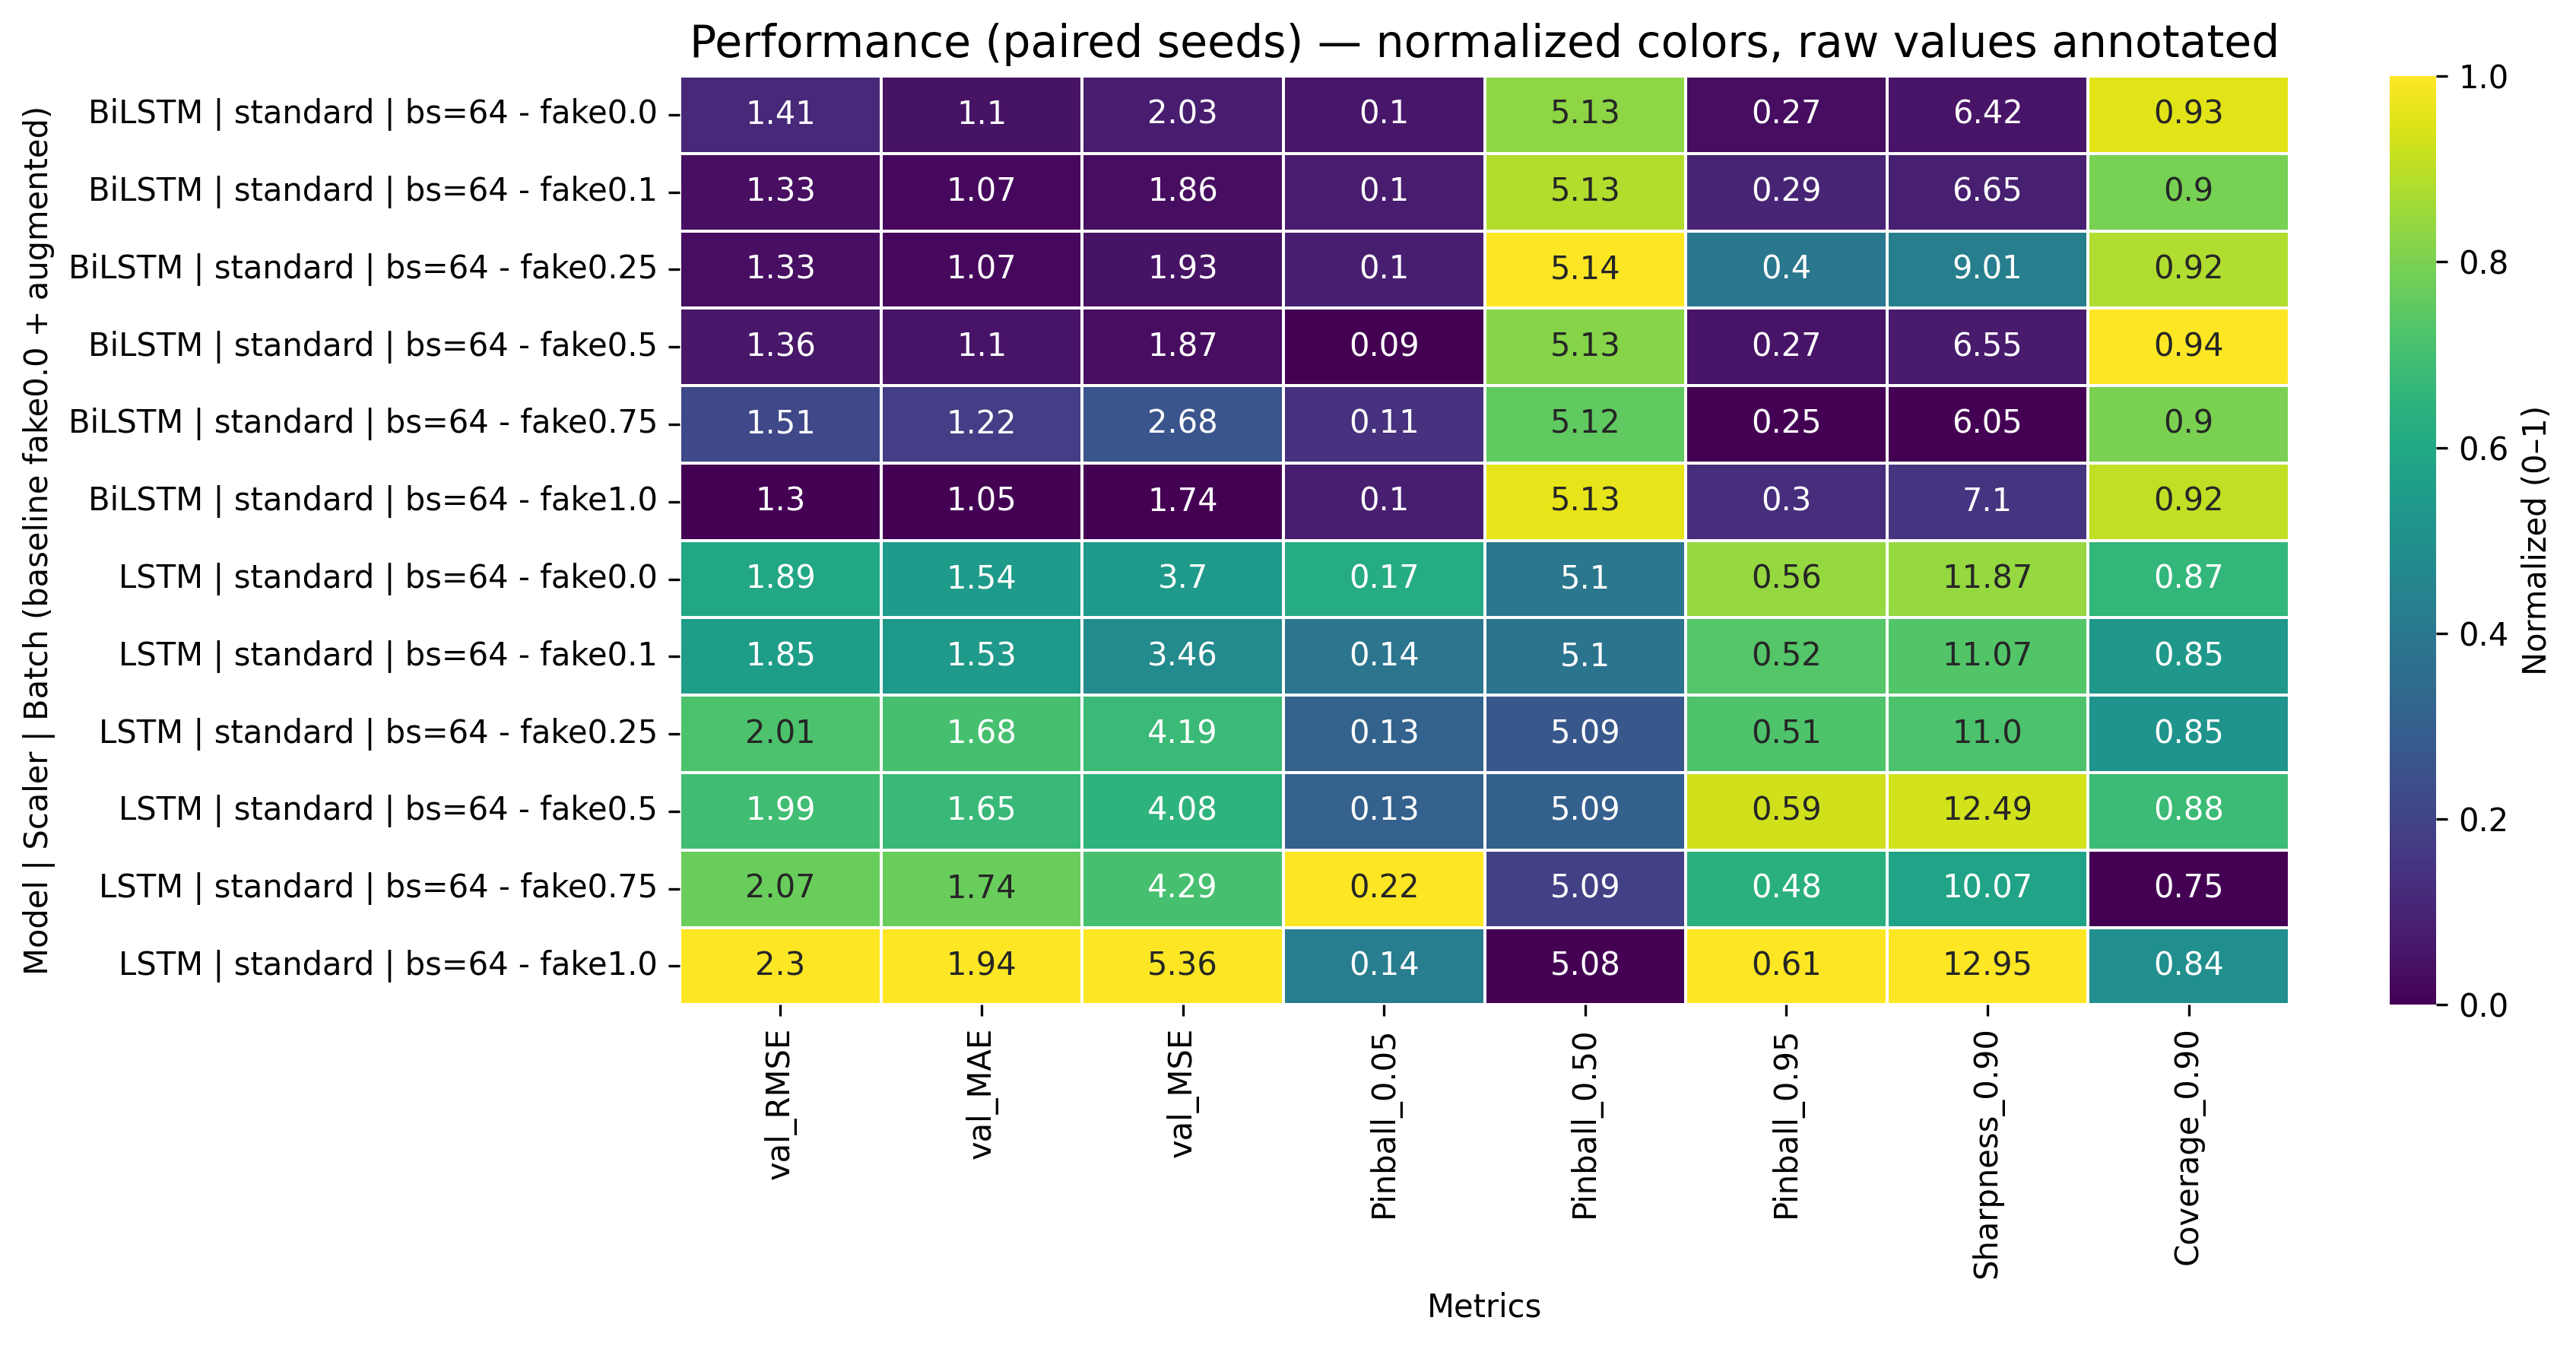

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# =========================
# Config
# =========================
# Include all metrics you want in the heatmap
METRICS = [
    'val_RMSE', 'val_MAE', 'val_MSE',
    'Pinball_0.05','Pinball_0.50','Pinball_0.95',
    'Sharpness_0.90','Coverage_0.90'
]

# =========================
# Core (paired -> heatmap table)
# =========================
def build_heatmap_table_from_paired(paired: pd.DataFrame, metrics=METRICS):
    """
    Uses the paired DataFrame (aug joined to its baseline per seed) to produce:
      - baseline means over the same (paired) seeds
      - augmented means per fake_data_length over the same seeds
    Returns a DataFrame indexed by:
      "model | scaler | bs=... - fake{len}"
    with columns = metrics (raw means).
    """
    # Neat labels
    paired = paired.copy()
    paired['config_base_lbl'] = (
        paired['model_name'] + ' | ' + paired['scaler_name'] + ' | bs=' + paired['batch_size'].astype(str)
    )
    paired['config_full'] = paired['config_base_lbl'] + ' - fake' + paired['fake_data_length'].astype(str)

    # Augmented means (over paired seeds)
    aug_means = (
        paired.groupby('config_full')[metrics]
        .mean()
    )

    # Baseline means (over the exact same paired seeds)
    base_cols = {m: f'{m}_base' for m in metrics}
    base_means = (
        paired.groupby('config_base_lbl')[[base_cols[m] for m in metrics]]
        .mean()
        .rename(columns={f'{m}_base': m for m in metrics})
    )
    # Put baseline rows first as fake0.0
    base_means.index = base_means.index + ' - fake0.0'

    # Combine & sort
    heatmap_raw = pd.concat([base_means, aug_means], axis=0).sort_index()
    return heatmap_raw

def normalize_per_metric_minmax(df: pd.DataFrame) -> pd.DataFrame:
    """Column-wise min-max normalization (0..1). Leaves all-NaN columns as NaN."""
    norm = df.copy()
    for c in norm.columns:
        col = norm[c].astype(float)
        cmin, cmax = col.min(), col.max()
        if np.isfinite(cmin) and np.isfinite(cmax) and cmax != cmin:
            norm[c] = (col - cmin) / (cmax - cmin)
        else:
            norm[c] = np.nan  # avoids divide-by-zero colors
    return norm

def plot_paired_heatmap(
    paired: pd.DataFrame,
    metrics=METRICS,
    save_path="Plots/heatmap_augmentation_quantiles.png",
    cmap="viridis",
    dpi=300
):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    heatmap_data = build_heatmap_table_from_paired(paired, metrics=metrics)
    normalized = normalize_per_metric_minmax(heatmap_data)

    # Figure height scales with number of rows
    h = max(6, 0.45 * len(heatmap_data))
    plt.figure(figsize=(12, h), dpi=dpi)
    sns.heatmap(
        normalized,
        annot=heatmap_data.round(2),
        fmt='',
        cmap=cmap,
        linewidths=0.5,
        cbar_kws={'label': 'Normalized (0–1)'}
    )
    plt.title("Performance (paired seeds) — normalized colors, raw values annotated", fontsize=14)
    plt.xlabel("Metrics")
    plt.ylabel("Model | Scaler | Batch (baseline fake0.0 + augmented)")
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()

# =========================
# =========================
def build_paired_from_df(df_all: pd.DataFrame, metrics=METRICS) -> pd.DataFrame:
    """
    Filters to test-stage, pairs each augmented run with its baseline (same model, scaler, batch, seed).
    Returns 'paired' with both augmented columns and *_base columns.
    """
    df_all = df_all[df_all['testing_stage'] == True].copy()
    keys = ['model_name', 'scaler_name', 'batch_size', 'seed']

    base = df_all[df_all['data_augmentation'] == False][keys + metrics].copy()
    aug  = df_all[df_all['data_augmentation'] == True][keys + ['fake_data_length'] + metrics].copy()

    base = base.rename(columns={m: f'{m}_base' for m in metrics})
    paired = aug.merge(base, on=keys, how='inner', validate='many_to_one')
    return paired

# =========================
# Usage
# =========================


# OR: build `paired` on the fly from your full df and then plot:
paired = build_paired_from_df(df, metrics=METRICS)
plot_paired_heatmap(paired, metrics=METRICS, save_path="Plots/heatmap_augmentation_quantiles.png")
